# LSTM Demand Forecasting (Weekly) - PROPHET-BEATING EDITION 🎯

**Goal: Beat Prophet's Test WAPE of 0.2837**

### What Was Wrong
The original LSTM with embeddings was **underfitting**:
- ❌ Hidden size too small (32) for 84 features
- ❌ Dropout too aggressive (0.5) killing signal
- ❌ Single layer can't capture complexity
- ❌ Baseline + offset approach limits expressiveness

### The Fixes
✅ **Larger capacity**: 64 hidden units, 2 LSTM layers  
✅ **Gentler regularization**: Dropout 0.3 instead of 0.5  
✅ **Direct prediction**: Remove baseline + offset, let model learn freely  
✅ **Better training**: Lower LR (1e-3), more patience (20 epochs)  
✅ **Keep embeddings**: They help, just need more model capacity  

Let's beat Prophet! 🏆


In [17]:
!pip install torch --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DATASETS_DIR = '../../datasets'
MODELS_DIR = '../../models/lstm'
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load Data & Features

In [19]:
df = pd.read_csv(os.path.join(DATASETS_DIR, 'forecasting_features_weekly.csv'),
                 parse_dates=['week_start'])

try:
    with open(os.path.join(DATASETS_DIR, 'feature_lists_weekly.json')) as f:
        feature_config = json.load(f)
    feature_cols = feature_config['dl_features']
    target_col = feature_config['target']
except FileNotFoundError:
    META = {'week_start', 'item_name', 'item_id', 'section', 'category',
            'holiday_type', 'split', 'quantity'}
    feature_cols = [c for c in df.columns
                    if c not in META
                    and df[c].dtype in ['int64', 'float64', 'int32', 'float32']]
    target_col = 'quantity'
    print("(feature_lists_weekly.json not found — derived features automatically)")

# Same identity-removal rule as XGB/LGB to keep apples-to-apples
for f in ['item_encoded', 'weeks_since_start']:
    if f in feature_cols:
        feature_cols.remove(f)

print(f"Loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"DL features: {len(feature_cols)}")
print(f"Target: {target_col}")
print(f"\nSplit distribution:")
print(df['split'].value_counts())

Loaded: 18,056 rows × 93 columns
DL features: 84
Target: quantity

Split distribution:
train    11712
test      4758
val       1586
Name: split, dtype: int64


## 2. Create Item Embeddings Index

In [20]:
# Create a mapping for item_ids to 0-indexed integers for embeddings
unique_items = sorted(df['item_id'].unique())
item_id_map = {id_val: i for i, id_val in enumerate(unique_items)}
df['item_id_idx'] = df['item_id'].map(item_id_map)

print(f"Total unique items: {len(unique_items)}")
print(f"Item ID range: {df['item_id_idx'].min()} to {df['item_id_idx'].max()}")

Total unique items: 122
Item ID range: 0 to 121


## 3. Build Sequences with Item IDs

In [21]:
SEQ_LEN = 12  # 12 weeks of history per prediction

def build_sequences(df_sub, feature_cols, target_col, seq_len=SEQ_LEN):
    """
    For each item, produce (X, y, item_idx, meta) where:
      X[i] = feature matrix for weeks t-seq_len ... t-1  (shape: seq_len × n_features)
      y[i] = target at week t
      item_idx[i] = item's embedding index
      meta[i] = (item_name, week_start, section, category, split)
    """
    X_list, y_list, item_idx_list, meta_list = [], [], [], []
    
    for item, item_df in df_sub.groupby('item_name', sort=False):
        item_df = item_df.sort_values('week_start').reset_index(drop=True)
        feats = item_df[feature_cols].values.astype(np.float32)
        target = item_df[target_col].values.astype(np.float32)
        item_idx = item_df['item_id_idx'].iloc[0]  # Get the integer index
        
        for t in range(seq_len, len(item_df)):
            X_list.append(feats[t-seq_len:t])
            y_list.append(target[t])
            item_idx_list.append(item_idx)
            meta_list.append({
                'item_name': item,
                'week_start': item_df['week_start'].iloc[t],
                'section': item_df['section'].iloc[t],
                'category': item_df['category'].iloc[t],
                'split': item_df['split'].iloc[t],
            })
    
    return np.stack(X_list), np.array(y_list), np.array(item_idx_list), pd.DataFrame(meta_list)

print("Building sequences (this may take ~30s)...")
X, y, item_idxs, meta = build_sequences(df, feature_cols, target_col)
print(f"Total sequences: {len(X):,}")
print(f"X shape: {X.shape}  (n_sequences × seq_len × n_features)")
print(f"y shape: {y.shape}")
print(f"item_idxs shape: {item_idxs.shape}")
print(f"\nSplit distribution among sequences:")
print(meta['split'].value_counts())

Building sequences (this may take ~30s)...
Total sequences: 16,592
X shape: (16592, 12, 84)  (n_sequences × seq_len × n_features)
y shape: (16592,)
item_idxs shape: (16592,)

Split distribution among sequences:
train    10248
test      4758
val       1586
Name: split, dtype: int64


## 4. Split & Standardize Data

In [22]:
# Splits computed from the *target week's* split label (not the sequence start)
train_mask = (meta['split'] == 'train').values
val_mask = (meta['split'] == 'val').values
test_mask = (meta['split'] == 'test').values

X_train, y_train, item_idxs_train = X[train_mask], y[train_mask], item_idxs[train_mask]
X_val, y_val, item_idxs_val = X[val_mask], y[val_mask], item_idxs[val_mask]
X_test, y_test, item_idxs_test = X[test_mask], y[test_mask], item_idxs[test_mask]

# Standardize features using TRAIN statistics only (no leakage)
feat_mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
feat_std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-6
X_train = (X_train - feat_mean) / feat_std
X_val = (X_val - feat_mean) / feat_std
X_test = (X_test - feat_mean) / feat_std

print(f"Train: {X_train.shape}  →  y mean={y_train.mean():.2f}, range [{y_train.min():.0f}, {y_train.max():.0f}]")
print(f"Val:   {X_val.shape}    →  y mean={y_val.mean():.2f}")
print(f"Test:  {X_test.shape}   →  y mean={y_test.mean():.2f}")

Train: (10248, 12, 84)  →  y mean=9.32, range [0, 43]
Val:   (1586, 12, 84)    →  y mean=7.73
Test:  (4758, 12, 84)   →  y mean=10.22


## 5. Enhanced LSTM Model with Item Embeddings

In [23]:
class DemandLSTM(nn.Module):
    def __init__(self, n_features, num_items, embed_dim=8, hidden_size=64, num_layers=2, dropout=0.3):
        """
        Enhanced LSTM with item embeddings - Direct Prediction Mode
        
        Changes from original:
        - Removed baseline + offset complexity
        - Larger hidden size (32 → 64) for 84 features
        - Deeper architecture (1 → 2 layers)
        - Gentler dropout (0.5 → 0.3)
        - Larger embeddings (6 → 8)
        """
        super().__init__()
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Simpler prediction head - direct prediction
        self.head = nn.Sequential(
            nn.Linear(hidden_size + embed_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x, item_idx):
        # x shape: (batch, seq_len, n_features)
        
        # Process sequence through LSTM
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]  # Take final timestep
        
        # Get item embedding
        item_emb = self.item_embedding(item_idx)
        
        # Combine and predict
        combined = torch.cat([last_step, item_emb], dim=1)
        prediction = self.head(combined).squeeze(-1)
        
        # Ensure non-negative predictions (inventory can't be negative)
        prediction = torch.nn.functional.softplus(prediction)
        
        return prediction

# Initialize model with better hyperparameters
EMBED_DIM = 8
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.3

model = DemandLSTM(
    n_features=len(feature_cols), 
    num_items=len(unique_items), 
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print(f"ENHANCED LSTM MODEL: {n_params:,} trainable parameters")
print("=" * 60)
print(model)
print(f"\nEmbedding layer: {len(unique_items)} items × {EMBED_DIM} dimensions")
print(f"LSTM: {NUM_LAYERS} layers × {HIDDEN_SIZE} hidden units")
print(f"Dropout: {DROPOUT}")


ENHANCED LSTM MODEL: 75,025 trainable parameters
DemandLSTM(
  (item_embedding): Embedding(122, 8)
  (lstm): LSTM(84, 64, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=72, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Embedding layer: 122 items × 8 dimensions
LSTM: 2 layers × 64 hidden units
Dropout: 0.3


## 6. Training Setup & Execution

In [24]:
# Dataset Class
class SeqDataset(Dataset):
    def __init__(self, X, y, item_idxs):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.item_idxs = torch.tensor(item_idxs, dtype=torch.long)  # Long is required for Embedding layers
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.item_idxs[i]

# Training Configuration
BATCH_SIZE = 128
MAX_EPOCHS = 100
PATIENCE = 20  # More patience for convergence
LEARNING_RATE = 1e-3  # Lower LR for stability
WEIGHT_DECAY = 1e-2

# Data Loaders
train_loader = DataLoader(
    SeqDataset(X_train, y_train, item_idxs_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    SeqDataset(X_val, y_val, item_idxs_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Optimizer & Scheduler
LEARNING_RATE = 1e-3  # Lower LR for stability
# Optimizer & Scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True)

criterion = nn.PoissonNLLLoss(log_input=False, full=False)

# Training history
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_mae = float('inf')
best_state = None
patience_counter = 0

print("=" * 60)
print("LSTM TRAINING WITH EMBEDDINGS — LIVE EPOCHS")
print("=" * 60)

start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    # --- TRAIN ---
    model.train()
    train_losses = []
    
    for xb, yb, item_idx_b in train_loader:
        xb, yb, item_idx_b = xb.to(device), yb.to(device), item_idx_b.to(device)
        
        optimizer.zero_grad()
        pred = model(xb, item_idx_b)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    # --- VALIDATE ---
    model.eval()
    val_losses, val_preds, val_targets = [], [], []
    
    with torch.no_grad():
        for xb, yb, item_idx_b in val_loader:
            xb, yb, item_idx_b = xb.to(device), yb.to(device), item_idx_b.to(device)
            pred = model(xb, item_idx_b)
            
            val_losses.append(criterion(pred, yb).item())
            val_preds.append(pred.cpu().numpy())
            val_targets.append(yb.cpu().numpy())
            
    val_preds = np.concatenate(val_preds)
    val_targets = np.concatenate(val_targets)
    val_mae = np.mean(np.abs(val_preds - val_targets))

    history['train_loss'].append(np.mean(train_losses))
    history['val_loss'].append(np.mean(val_losses))
    history['val_mae'].append(val_mae)
    scheduler.step(val_mae)

    # Early stopping
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}  train_loss={np.mean(train_losses):.4f}  val_loss={np.mean(val_losses):.4f}  val_mae={val_mae:.4f}  best={best_val_mae:.4f}")
    
    if patience_counter >= PATIENCE:
        print(f"  Early stopping at epoch {epoch}")
        break

training_time = time.time() - start_time
model.load_state_dict(best_state)

print(f"\n{'='*60}")
print(f"✓ Training complete: {training_time:.1f}s")
print(f"✓ Best val MAE:      {best_val_mae:.4f}")
print(f"{'='*60}")

LSTM TRAINING WITH EMBEDDINGS — LIVE EPOCHS
  Epoch   1  train_loss=-4.8231  val_loss=-8.6254  val_mae=3.0198  best=3.0198
  Epoch   5  train_loss=-12.3345  val_loss=-8.8583  val_mae=2.5286  best=2.5286
  Epoch  10  train_loss=-12.3165  val_loss=-8.8514  val_mae=2.5624  best=2.5286
  Epoch  15  train_loss=-12.4832  val_loss=-8.7828  val_mae=2.7541  best=2.4542
  Epoch  20  train_loss=-12.3738  val_loss=-8.8303  val_mae=2.6139  best=2.4542
  Epoch  25  train_loss=-12.4413  val_loss=-8.8290  val_mae=2.6174  best=2.4542
  Epoch  30  train_loss=-12.4669  val_loss=-8.8006  val_mae=2.6984  best=2.4542
  Early stopping at epoch 33

✓ Training complete: 68.0s
✓ Best val MAE:      2.4542


## 7. Learning Curves

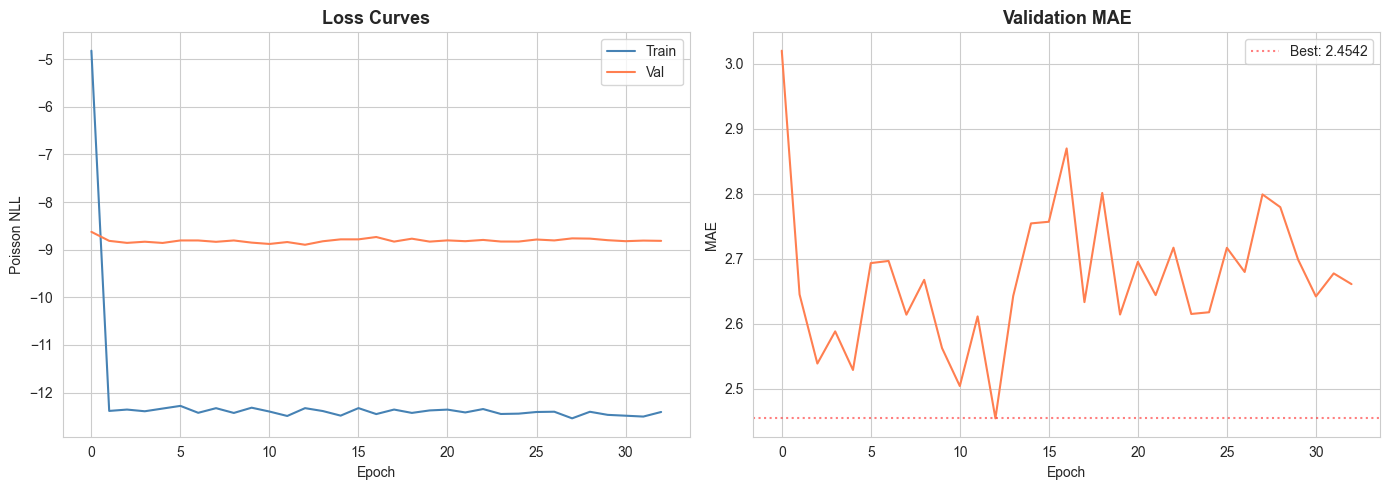

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'], label='Val', color='coral')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Poisson NLL')
axes[0].legend()

axes[1].plot(history['val_mae'], color='coral')
axes[1].set_title('Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].axhline(best_val_mae, color='red', linestyle=':', alpha=0.5, label=f'Best: {best_val_mae:.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Generate Predictions

In [26]:
model.eval()

def predict(X_arr, item_idxs_arr):
    """Generate predictions with item embeddings"""
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_arr), BATCH_SIZE):
            batch_X = torch.tensor(X_arr[i:i+BATCH_SIZE], dtype=torch.float32).to(device)
            batch_items = torch.tensor(item_idxs_arr[i:i+BATCH_SIZE], dtype=torch.long).to(device)
            preds.append(model(batch_X, batch_items).cpu().numpy())
    return np.concatenate(preds)

val_preds = predict(X_val, item_idxs_val)
test_preds = predict(X_test, item_idxs_test)

predictions_df = pd.concat([
    meta[val_mask].assign(actual=y_val, predicted=val_preds).rename(columns={'week_start': 'ds'}),
    meta[test_mask].assign(actual=y_test, predicted=test_preds).rename(columns={'week_start': 'ds'}),
])
predictions_df['predicted'] = predictions_df['predicted'].clip(lower=0)

print(f"Val predictions:  {len(val_preds):,} rows")
print(f"Test predictions: {len(test_preds):,} rows")
print(f"Total: {len(predictions_df):,}")

Val predictions:  1,586 rows
Test predictions: 4,758 rows
Total: 6,344


## 9. Evaluation Metrics

In [27]:
def compute_metrics(actual, predicted, train_actual=None):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = actual - predicted
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt((errors**2).mean())
    bias = errors.mean()

    nonzero = actual > 0
    mape = (abs_errors[nonzero] / actual[nonzero]).mean() if nonzero.sum() > 0 else np.nan

    denom = (np.abs(actual) + np.abs(predicted)) / 2
    smape_mask = denom > 0
    smape = (abs_errors[smape_mask] / denom[smape_mask]).mean() if smape_mask.sum() > 0 else np.nan

    actual_sum = actual.sum()
    wape = abs_errors.sum() / actual_sum if actual_sum > 0 else np.inf

    ss_res = (errors**2).sum()
    ss_tot = ((actual - actual.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    mase = np.nan
    if train_actual is not None and len(train_actual) > 52:
        naive_errors = np.abs(train_actual[52:] - train_actual[:-52])
        mae_naive = naive_errors.mean()
        if mae_naive > 0:
            mase = mae / mae_naive

    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'smape': smape,
            'wape': wape, 'mase': mase, 'r2': r2, 'bias': bias}

print("Metric function ready")

Metric function ready


## 10. Overall Performance vs Baseline Models

LSTM OVERALL METRICS (weekly)
Model Split    mae   rmse  smape   wape     r2    bias
 lstm   val 2.4542 3.2446 0.3819 0.3175 0.6165 -0.2414
 lstm  test 2.7361 3.6430 0.3107 0.2676 0.6401  0.8277

BARS TO BEAT (test split)
   Model   wape     r2
 Prophet 0.2837 0.6196
 XGBoost 0.2614 0.6707
LightGBM 0.2617 0.6681
    LSTM 0.2676 0.6401


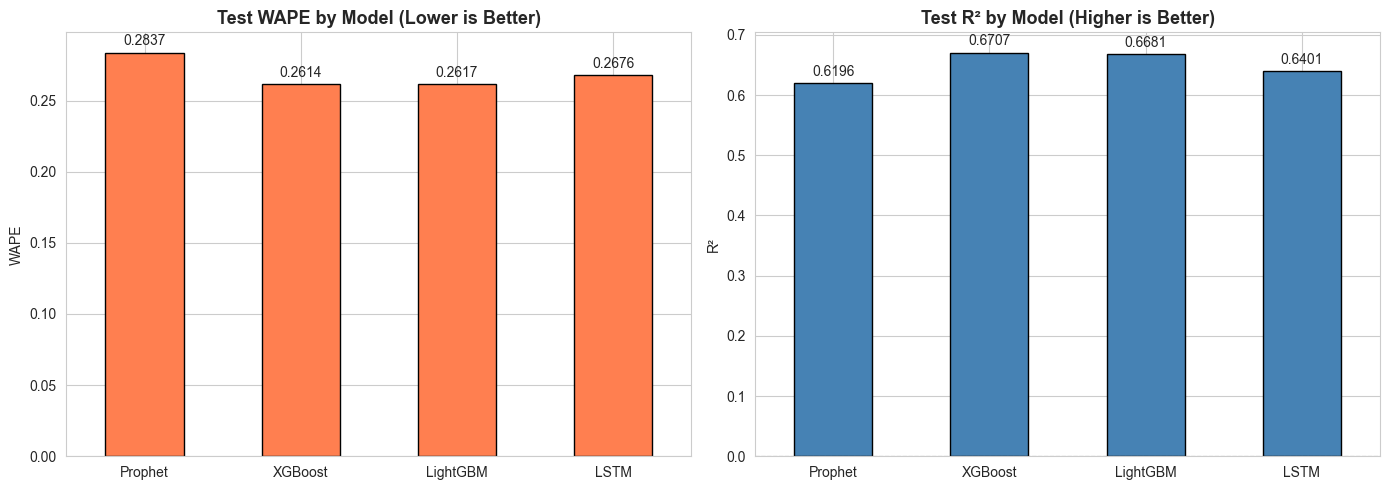

In [28]:
# Compute LSTM overall metrics
rows = []
for split in ['val', 'test']:
    sub = predictions_df[predictions_df['split'] == split]
    m = compute_metrics(sub['actual'].values, sub['predicted'].values)
    rows.append({'Model': 'lstm', 'Split': split, **m})

lstm_overall = pd.DataFrame(rows).drop(columns=['mape', 'mase'], errors='ignore')
print("=" * 80)
print("LSTM OVERALL METRICS (weekly)")
print("=" * 80)
print(lstm_overall.to_string(index=False, float_format='%.4f'))

# Compare with baseline models
LIGHTGBM_DIR = '../LightGbm'
XGBOOST_DIR = '../XGboost'
PROPHET_DIR = '../Prophet'

try:
    with open(os.path.join(PROPHET_DIR, 'prophet_summary_weekly.json')) as f:
        prophet_sum = json.load(f)
    with open(os.path.join(XGBOOST_DIR, 'xgboost_weekly_summary.json')) as f:
        xgb_sum = json.load(f)
    with open(os.path.join(LIGHTGBM_DIR, 'lightgbm_weekly_summary.json')) as f:
        lgb_sum = json.load(f)

    print()
    print("=" * 80)
    print("BARS TO BEAT (test split)")
    print("=" * 80)
    bars = pd.DataFrame([
        {'Model': 'Prophet', **{k: prophet_sum['overall_metrics']['test'][k] for k in ['wape', 'r2']}},
        {'Model': 'XGBoost', **{k: xgb_sum['overall_metrics']['test'][k] for k in ['wape', 'r2']}},
        {'Model': 'LightGBM', **{k: lgb_sum['overall_metrics']['test'][k] for k in ['wape', 'r2']}},
        {'Model': 'LSTM', 'wape': rows[1]['wape'], 'r2': rows[1]['r2']},
    ])
    print(bars.to_string(index=False, float_format='%.4f'))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # WAPE (Lower is Better)
    bars.plot(kind='bar', x='Model', y='wape', ax=axes[0], color='coral', edgecolor='black', legend=False)
    axes[0].set_title('Test WAPE by Model (Lower is Better)', fontweight='bold')
    axes[0].set_ylabel('WAPE')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=0)
    
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points')

    # R² (Higher is Better)
    bars.plot(kind='bar', x='Model', y='r2', ax=axes[1], color='steelblue', edgecolor='black', legend=False)
    axes[1].set_title('Test R² by Model (Higher is Better)', fontweight='bold')
    axes[1].set_ylabel('R²')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points')

    plt.tight_layout()
    plt.savefig('lstm_vs_baselines.png', dpi=150, bbox_inches='tight')
    plt.show()

except FileNotFoundError as e:
    print(f"(Comparison files not yet present: {e})")

## 11. Per-Item Metrics

In [29]:
per_item_metrics = []
for item in sorted(predictions_df['item_name'].unique()):
    item_pred = predictions_df[predictions_df['item_name'] == item]
    item_train = df[(df['item_name'] == item) & (df['split'] == 'train')]['quantity'].values
    
    for split in ['val', 'test']:
        sub = item_pred[item_pred['split'] == split]
        if len(sub) == 0:
            continue
        m = compute_metrics(sub['actual'].values, sub['predicted'].values, item_train)
        m.update({'item_name': item, 'split': split})
        per_item_metrics.append(m)

metrics_df = pd.DataFrame(per_item_metrics)
print(f"Per-item metrics: {len(metrics_df)} rows")
print(metrics_df.groupby('split')[['mae', 'wape', 'r2']].mean().round(4))

Per-item metrics: 244 rows
          mae    wape      r2
split                        
test   2.7361  0.2946 -0.0493
val    2.4542  0.3594  0.0065


## 12. Performance by Section

LSTM — Performance by Section
      Section Split    MAE   WAPE     R²    Bias  n_items
     American   val 3.0552 0.2847 0.6565  0.0867       21
         Cafe   val 3.1756 0.3474 0.4234 -0.9736       17
Healthy_Vegan   val 1.8008 0.3574 0.3685 -0.5270       12
      Italian   val 2.1812 0.3064 0.6198 -0.2552       22
     Japanese   val 2.2729 0.3156 0.5136 -0.1910       16
      Mexican   val 2.4068 0.3179 0.5887  0.0406       19
   Steakhouse   val 1.9716 0.3433 0.4387 -0.0336       15
     American  test 3.2737 0.2438 0.7052  1.5373       21
         Cafe  test 3.2153 0.2341 0.4747  1.2712       17
Healthy_Vegan  test 2.5041 0.3030 0.3718  0.6878       12
      Italian  test 2.5707 0.2774 0.4876  0.2861       22
     Japanese  test 2.7107 0.2833 0.5400  0.8963       16
      Mexican  test 2.5548 0.2790 0.5374  0.4558       19
   Steakhouse  test 2.1255 0.3133 0.5312  0.6357       15


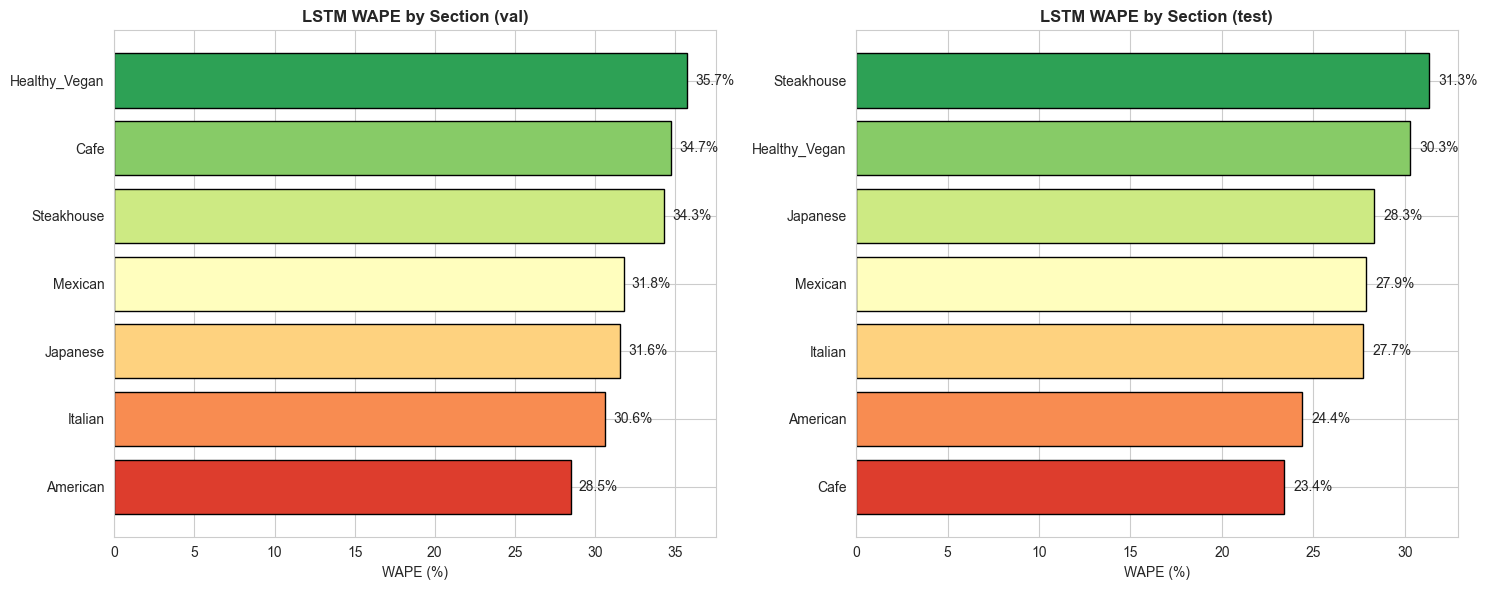

In [30]:
section_results = []
for split in ['val', 'test']:
    sub = predictions_df[predictions_df['split'] == split]
    for section in sorted(sub['section'].unique()):
        sec = sub[sub['section'] == section]
        if len(sec) == 0 or sec['actual'].sum() == 0:
            continue
        m = compute_metrics(sec['actual'].values, sec['predicted'].values)
        section_results.append({
            'Section': section, 'Split': split,
            'MAE': m['mae'], 'WAPE': m['wape'], 'R²': m['r2'], 'Bias': m['bias'],
            'n_items': sec['item_name'].nunique(),
        })

section_df = pd.DataFrame(section_results)
print("=" * 80)
print("LSTM — Performance by Section")
print("=" * 80)
print(section_df.to_string(index=False, float_format='%.4f'))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, split in zip(axes, ['val', 'test']):
    sec_data = section_df[section_df['Split'] == split].sort_values('WAPE', ascending=False)
    wape_pct = sec_data['WAPE'] * 100
    
    bars = ax.barh(sec_data['Section'], wape_pct, 
                   color=sns.color_palette('RdYlGn_r', len(sec_data)), 
                   edgecolor='black')
    ax.invert_yaxis()
    ax.set_title(f'LSTM WAPE by Section ({split})', fontweight='bold', fontsize=12)
    ax.set_xlabel('WAPE (%)')
    ax.set_ylabel('')
    
    for bar, val in zip(bars, wape_pct):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.savefig('lstm_weekly_per_section.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Performance by Volume Tier

LSTM — Performance by Volume Tier
     volume_tier split  n_items    mae   wape  smape      r2
     Low (<7/wk)  test       46 2.0037 0.3575 0.3834 -0.0130
     Low (<7/wk)   val       46 1.7869 0.4330 0.4633 -0.0224
Medium (7-35/wk)  test       76 3.1794 0.2565 0.2667 -0.0713
Medium (7-35/wk)   val       76 2.8581 0.3148 0.3326  0.0240


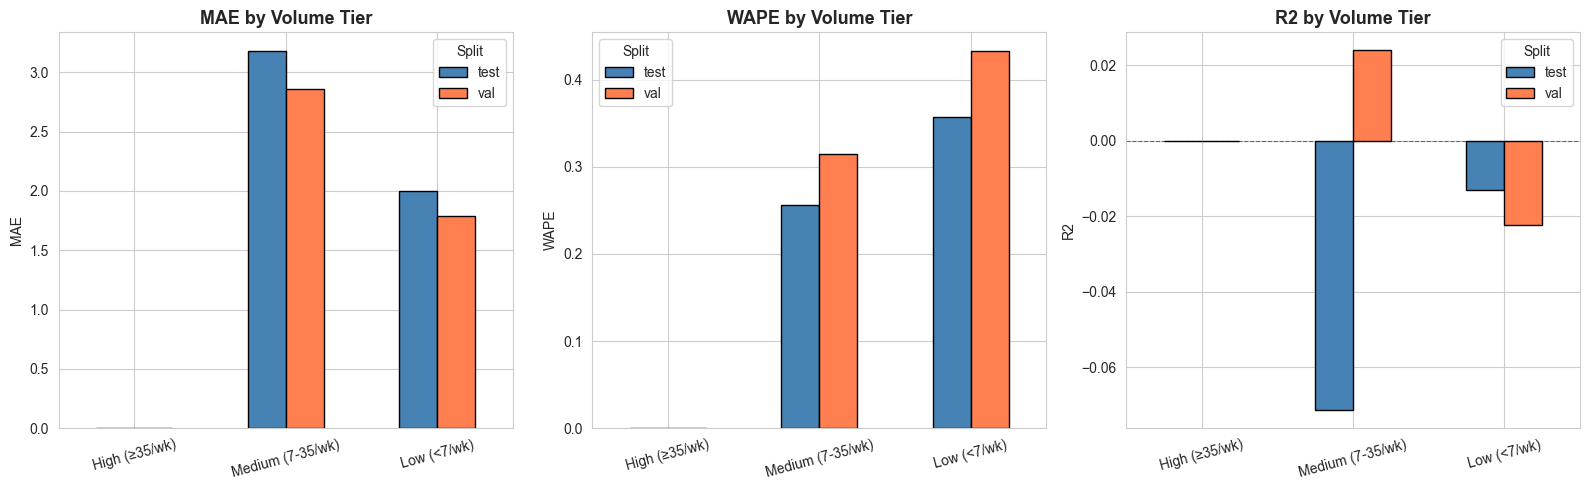

In [31]:
df_orig = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'),
                       parse_dates=['week_start'])
item_volume = df_orig[df_orig['split']=='train'].groupby('item_name')['quantity'].mean()

def assign_tier(avg):
    if avg >= 35: return 'High (≥35/wk)'
    elif avg >= 7: return 'Medium (7-35/wk)'
    else: return 'Low (<7/wk)'

item_tiers = item_volume.apply(assign_tier).rename('volume_tier').reset_index()
metrics_with_tier = metrics_df.merge(item_tiers, on='item_name')

tier_results = metrics_with_tier.groupby(['volume_tier', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'),
    wape=('wape', 'mean'),
    smape=('smape', 'mean'),
    r2=('r2', 'mean'),
).reset_index()

print("=" * 70)
print("LSTM — Performance by Volume Tier")
print("=" * 70)
print(tier_results.to_string(index=False, float_format='%.4f'))

# Visualization
tier_order = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['mae', 'wape', 'r2']):
    pivot = tier_results.pivot(index='volume_tier', columns='split', values=metric).reindex(tier_order)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric.upper()} by Volume Tier', fontweight='bold')
    ax.set_ylabel(metric.upper())
    ax.set_xlabel('')
    ax.legend(title='Split')
    ax.tick_params(axis='x', rotation=15)
    if metric == 'r2':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('lstm_weekly_by_volume_tier.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Sample Predictions Visualization

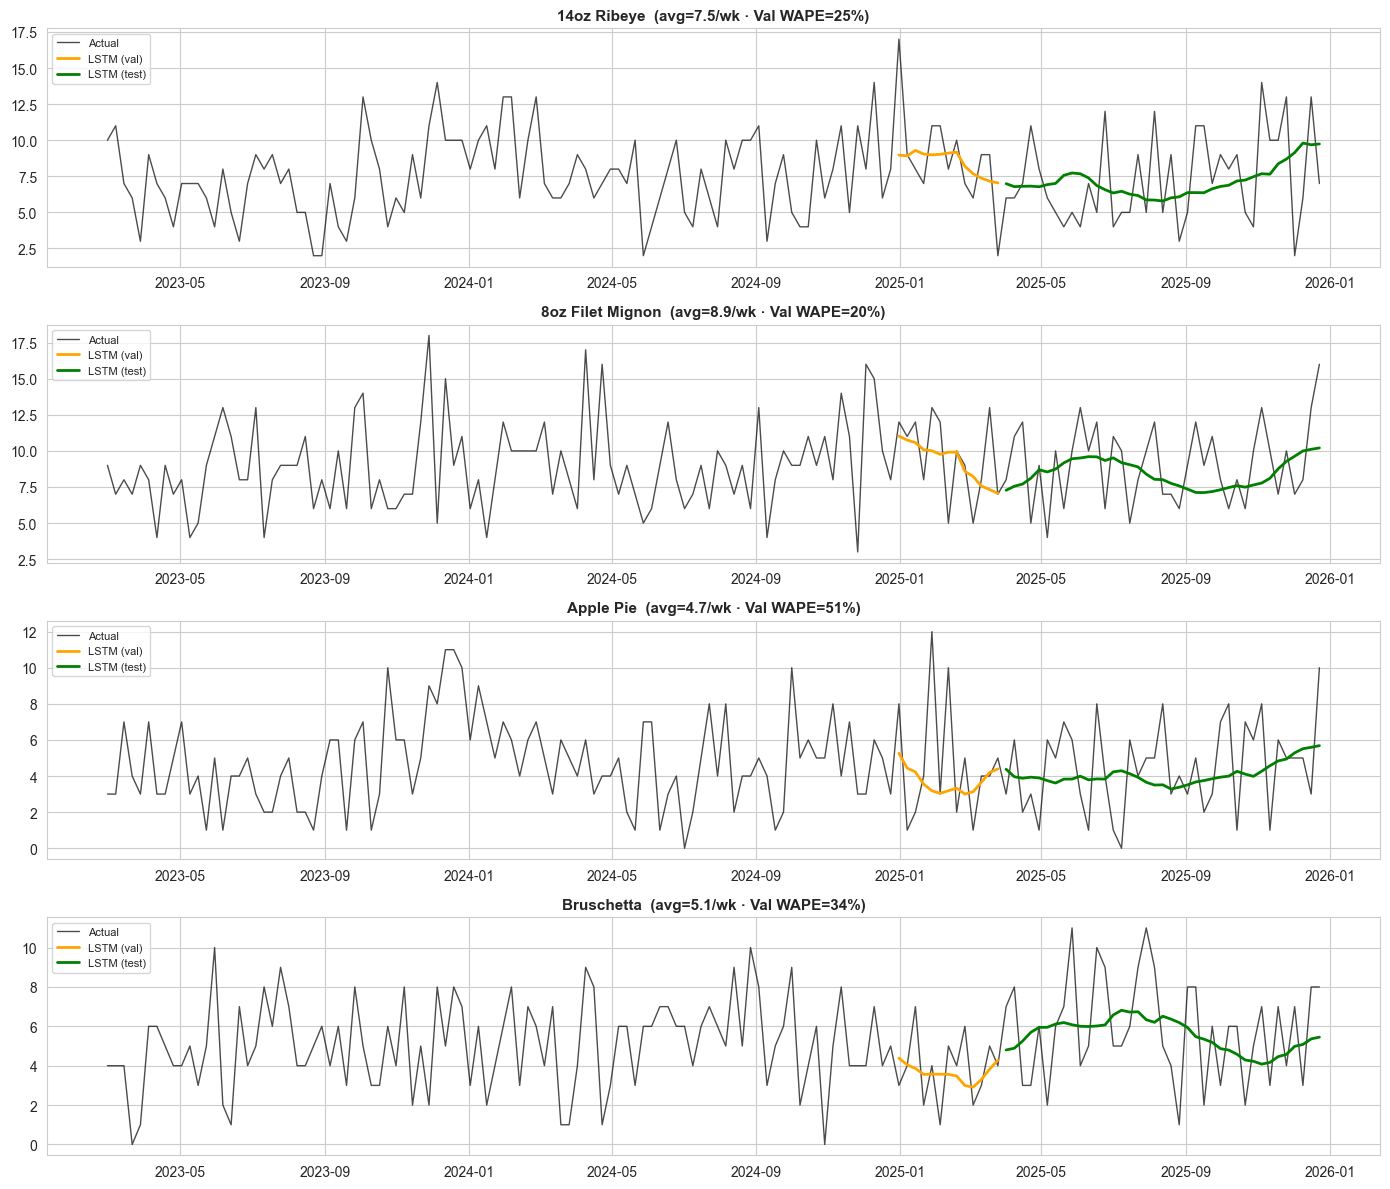

In [32]:
tier_order = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']
sample_items = []

for tier in tier_order:
    tier_items = item_tiers[item_tiers['volume_tier'] == tier]['item_name'].tolist()
    if len(tier_items) >= 2:
        sample_items.extend(tier_items[:2])
    elif tier_items:
        sample_items.extend(tier_items[:1])

fig, axes = plt.subplots(len(sample_items), 1, figsize=(14, 3*len(sample_items)))
if len(sample_items) == 1:
    axes = [axes]

for ax, item in zip(axes, sample_items):
    item_full = df[df['item_name'] == item].sort_values('week_start')
    item_pred = predictions_df[predictions_df['item_name'] == item].sort_values('ds')
    avg = df_orig[df_orig['item_name']==item]['quantity'].mean()

    ax.plot(item_full['week_start'], item_full['quantity'], color='black', linewidth=1, label='Actual', alpha=0.7)
    
    val_p = item_pred[item_pred['split']=='val']
    test_p = item_pred[item_pred['split']=='test']
    
    if len(val_p):
        ax.plot(val_p['ds'], val_p['predicted'], color='orange', linewidth=2, label='LSTM (val)')
    if len(test_p):
        ax.plot(test_p['ds'], test_p['predicted'], color='green', linewidth=2, label='LSTM (test)')

    val_wape = metrics_df[(metrics_df['item_name']==item) & (metrics_df['split']=='val')]['wape'].values
    val_wape_str = f"{val_wape[0]:.0%}" if len(val_wape) else 'n/a'
    
    ax.set_title(f"{item}  (avg={avg:.1f}/wk · Val WAPE={val_wape_str})", fontsize=11)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('lstm_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Residual Diagnostics

Validation residual statistics:
  Mean:     -0.2414
  Median:   -0.4256
  Std:      3.2356
  Skewness: 0.4301
  Kurtosis: 1.3936


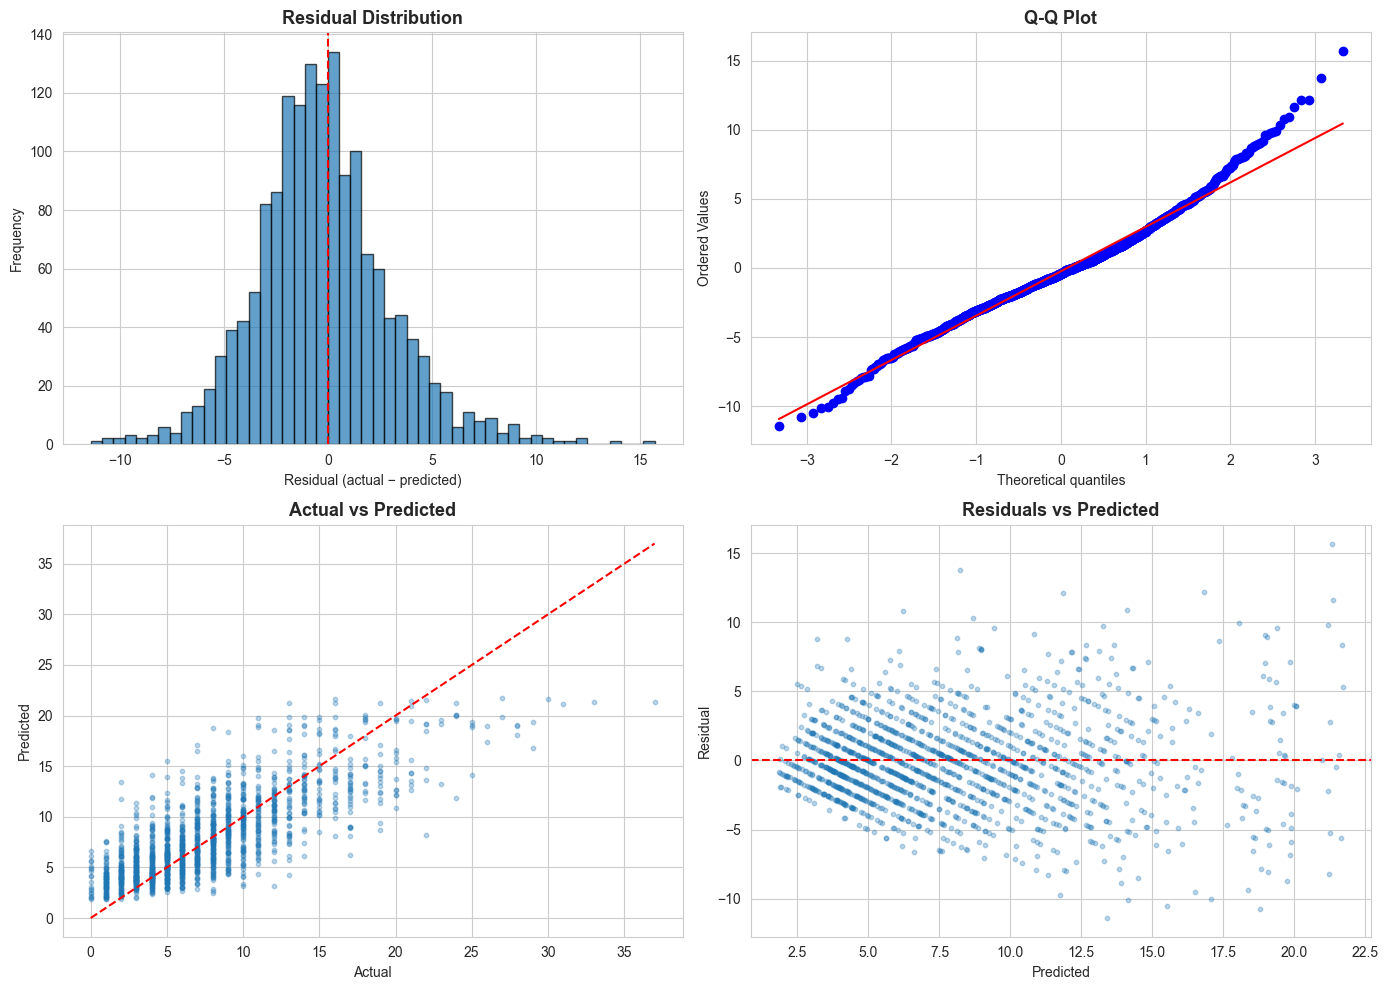

In [33]:
from scipy import stats as sp_stats

val_pred = predictions_df[predictions_df['split'] == 'val'].copy()
val_pred['residual'] = val_pred['actual'] - val_pred['predicted']

residuals = val_pred['residual'].values
print("Validation residual statistics:")
print(f"  Mean:     {residuals.mean():.4f}")
print(f"  Median:   {np.median(residuals):.4f}")
print(f"  Std:      {residuals.std():.4f}")
print(f"  Skewness: {pd.Series(residuals).skew():.4f}")
print(f"  Kurtosis: {pd.Series(residuals).kurtosis():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0,0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_title('Residual Distribution')
axes[0,0].set_xlabel('Residual (actual − predicted)')
axes[0,0].set_ylabel('Frequency')

# Q-Q plot
sp_stats.probplot(residuals, dist='norm', plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot')

# Actual vs predicted
axes[1,0].scatter(val_pred['actual'], val_pred['predicted'], alpha=0.3, s=10)
lim = max(val_pred['actual'].max(), val_pred['predicted'].max())
axes[1,0].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[1,0].set_title('Actual vs Predicted')
axes[1,0].set_xlabel('Actual')
axes[1,0].set_ylabel('Predicted')

# Residuals vs predicted
axes[1,1].scatter(val_pred['predicted'], residuals, alpha=0.3, s=10)
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,1].set_title('Residuals vs Predicted')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('lstm_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. WAPE Distribution Analysis

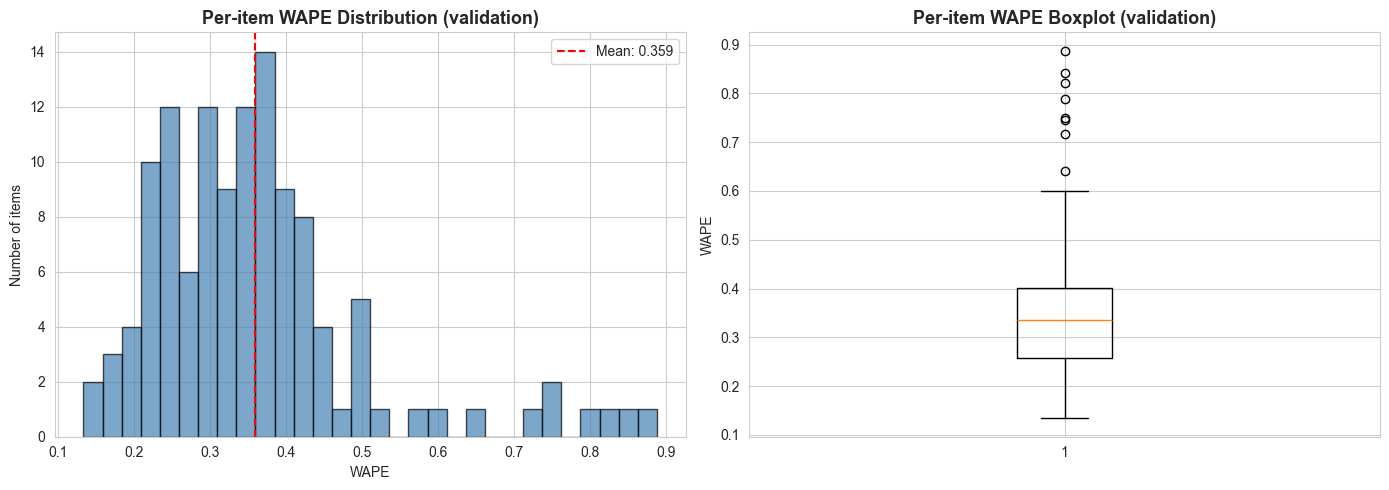


Top 10 best items (lowest val WAPE):
                item_name    mae   wape      r2
              Dragon Roll 1.3794 0.1338 -0.5776
          Spicy Tuna Roll 1.6256 0.1488  0.2209
       Fettuccine Alfredo 2.1704 0.1660  0.4318
                 Horchata 0.8358 0.1781  0.1378
Herb-Crusted Rack of Lamb 1.6132 0.1840  0.3525
       Philly Cheesesteak 2.7392 0.1864  0.1987
         Margherita Pizza 1.8068 0.1879  0.2433
             Garlic Bread 1.7955 0.1929  0.5346
         8oz Filet Mignon 1.9053 0.1982  0.0886
                Diet Coke 2.3321 0.2150  0.2817

Top 10 worst items (highest val WAPE):
                item_name    mae   wape      r2
        Chocolate Brownie 2.2537 0.5860 -0.2148
          Modelo Especial 2.3560 0.6006  0.0280
                 Prosecco 2.3646 0.6404 -0.5364
           Fruit Smoothie 2.9261 0.7177 -0.8272
        Grilled Asparagus 2.4658 0.7455 -1.1090
             Lemon Gelato 1.2696 0.7502 -0.0369
        Vanilla Milkshake 2.0638 0.7891  0.0130
          

In [34]:
val_item_wape = metrics_df[metrics_df['split'] == 'val']['wape'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(val_item_wape, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Per-item WAPE Distribution (validation)')
axes[0].set_xlabel('WAPE')
axes[0].set_ylabel('Number of items')
axes[0].axvline(val_item_wape.mean(), color='red', linestyle='--', 
                label=f'Mean: {val_item_wape.mean():.3f}')
axes[0].legend()

axes[1].boxplot(val_item_wape, vert=True)
axes[1].set_title('Per-item WAPE Boxplot (validation)')
axes[1].set_ylabel('WAPE')

plt.tight_layout()
plt.savefig('lstm_wape_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Best and worst items
val_items = metrics_df[metrics_df['split'] == 'val'].sort_values('wape')
print("\nTop 10 best items (lowest val WAPE):")
print(val_items.head(10)[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))
print("\nTop 10 worst items (highest val WAPE):")
print(val_items.tail(10)[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))

## 17. Save Outputs

In [35]:
# Save model state
torch.save({
    'state_dict': model.state_dict(),
    'feat_mean': feat_mean,
    'feat_std': feat_std,
    'feature_cols': feature_cols,
    'seq_len': SEQ_LEN,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'embed_dim': EMBED_DIM,
    'dropout': DROPOUT,
    'num_items': len(unique_items),
    'item_id_map': item_id_map,
}, os.path.join(MODELS_DIR, 'model.pt'))

# Save predictions
pred_out = predictions_df.rename(columns={'ds': 'ds'})[[
    'ds', 'item_name', 'section', 'category', 'actual', 'predicted', 'split'
]]
pred_out.to_csv(os.path.join(DATASETS_DIR, 'lstm_predictions_weekly.csv'), index=False)

# Save per-item metrics
metrics_df.to_csv(os.path.join(DATASETS_DIR, 'lstm_metrics_weekly.csv'), index=False)

# Save summary
summary = {
    'model': 'lstm',
    'arch': {
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'seq_len': SEQ_LEN,
        'embed_dim': EMBED_DIM,
        'dropout': DROPOUT,
        'num_items': len(unique_items),
    },
    'training_time_sec': round(training_time, 1),
    'epochs_run': epoch,
    'best_val_mae': float(best_val_mae),
    'overall_metrics': {
        split: {k: float(v) for k, v in compute_metrics(
            predictions_df[predictions_df['split']==split]['actual'].values,
            predictions_df[predictions_df['split']==split]['predicted'].values,
        ).items() if k != 'mase' and not (isinstance(v, float) and np.isnan(v))}
        for split in ['val', 'test']
    },
}

with open(os.path.join(DATASETS_DIR, 'lstm_summary_weekly.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 60)
print("✓ Saved:")
print(f"  Model:       {os.path.join(MODELS_DIR, 'model.pt')}")
print(f"  Predictions: lstm_predictions_weekly.csv")
print(f"  Metrics:     lstm_metrics_weekly.csv")
print(f"  Summary:     lstm_summary_weekly.json")
print("=" * 60)

✓ Saved:
  Model:       ../../models/lstm\model.pt
  Predictions: lstm_predictions_weekly.csv
  Metrics:     lstm_metrics_weekly.csv
  Summary:     lstm_summary_weekly.json
